# Modelos de difusión

> Cómo se aprende a generar imágenes deshaciendo ruido: un proceso directo que destruye poco a poco una imagen hasta dejar ruido gaussiano y una red que aprende a recorrer el camino inverso, paso a paso. El DDPM entrenado sobre MNIST con una red densa y con una U-Net pequeña, qué aprende la red en cada nivel de ruido, el muestreo acelerado con DDIM y una comparación cuantitativa con la DCGAN del notebook anterior.
>
> **Requisitos previos:** [Redes convolucionales](03-redes-convolucionales.ipynb) · [GAN](08-gan.ipynb) · **Relacionado:** [Autoencoders](05-autoencoders.ipynb) · [Atención y transformers](07-atencion-y-transformers.ipynb)

## 1. Idea clave

Destruir una imagen es fácil: basta con añadirle ruido gaussiano poco a poco hasta que no quede nada de ella. Un **modelo de difusión** aprende a hacer lo contrario: se entrena una red que, dada una imagen ruidosa y el nivel de ruido, **predice el ruido** que se le añadió. Para generar, se parte de ruido puro y se aplica esa red cientos de veces, quitando un poco de ruido en cada paso, hasta llegar a una imagen nueva.

El entrenamiento es tan sencillo como una regresión (una sola red y un error cuadrático medio, sin juego adversario), es estable y cubre bien toda la variedad de los datos. Por eso los modelos de difusión son hoy el estándar en generación de imagen, audio y vídeo (Stable Diffusion, DALL·E 2, Imagen). Su precio es la **lentitud al generar**: cientos de pasadas por la red frente a una sola de una [GAN](08-gan.ipynb). Los muestreadores acelerados como DDIM reducen ese coste a decenas de pasos.

## 2. Conceptos importantes

### 2.1. Proceso directo: de imagen a ruido

Se fija un número de pasos $T$ (habitualmente 1000) y una **programación de varianzas** (*noise schedule*) $\beta_1<\beta_2<\dots<\beta_T$, pequeñas (aquí crecen linealmente de $10^{-4}$ a $0{,}02$). En cada paso la imagen se encoge un poco y se le suma ruido:

$$
q(\mathbf{x}_t\mid\mathbf{x}_{t-1})=\mathcal{N}\!\left(\sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\;\beta_t\mathbf{I}\right),
$$

donde $\mathbf{x}_0$ es la imagen real y $\mathbf{x}_t$ la imagen tras $t$ pasos. Este proceso **no tiene parámetros**: no se aprende. Con $\alpha_t=1-\beta_t$ y $\bar\alpha_t=\prod_{s=1}^{t}\alpha_s$ (cuánta "señal" sobrevive tras $t$ pasos), encadenar gaussianas da una fórmula cerrada para saltar directamente a cualquier paso:

$$
\mathbf{x}_t=\sqrt{\bar\alpha_t}\,\mathbf{x}_0+\sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon},\qquad\boldsymbol{\epsilon}\sim\mathcal{N}(\mathbf{0},\mathbf{I}).
$$

$\bar\alpha_t$ baja de casi 1 a casi 0: al final $\mathbf{x}_T$ es prácticamente ruido $\mathcal{N}(\mathbf{0},\mathbf{I})$, que es justo de donde partirá la generación. La fórmula cerrada es la que hace barato el entrenamiento: no hay que simular los $t$ pasos.

### 2.2. Proceso inverso: de ruido a imagen

Para generar habría que invertir cada paso, $q(\mathbf{x}_{t-1}\mid\mathbf{x}_t)$, que depende de la distribución de los datos y no se conoce. Si los $\beta_t$ son pequeños, ese paso inverso es aproximadamente gaussiano, así que se aproxima con una gaussiana cuya media calcula una red de parámetros $\theta$:

$$
p_\theta(\mathbf{x}_{t-1}\mid\mathbf{x}_t)=\mathcal{N}\!\left(\boldsymbol{\mu}_\theta(\mathbf{x}_t,t),\;\sigma_t^2\mathbf{I}\right),\qquad\sigma_t^2=\beta_t.
$$

En el **DDPM** (*denoising diffusion probabilistic model*, Ho et al., 2020) la red no predice la media directamente, sino el **ruido** $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)$ contenido en $\mathbf{x}_t$, y la media se obtiene de él:

$$
\boldsymbol{\mu}_\theta(\mathbf{x}_t,t)=\frac{1}{\sqrt{\alpha_t}}\left(\mathbf{x}_t-\frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)\right).
$$

**Generar** (algoritmo de muestreo del DDPM): se parte de $\mathbf{x}_T\sim\mathcal{N}(\mathbf{0},\mathbf{I})$ y, para $t=T,\dots,1$, se calcula $\mathbf{x}_{t-1}=\boldsymbol{\mu}_\theta(\mathbf{x}_t,t)+\sigma_t\mathbf{z}$ con $\mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I})$, salvo en el último paso, donde no se añade ruido. Son $T$ pasadas por la red.

### 2.3. Entrenamiento: predecir el ruido

La pérdida que se deriva de maximizar la verosimilitud (una cota inferior, como en el VAE) se simplifica, quitando unos pesos, a un error cuadrático medio:

$$
\mathcal{L}=\mathbb{E}_{\mathbf{x}_0,\,t,\,\boldsymbol{\epsilon}}\left[\big\|\boldsymbol{\epsilon}-\boldsymbol{\epsilon}_\theta\big(\sqrt{\bar\alpha_t}\,\mathbf{x}_0+\sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon},\;t\big)\big\|^2\right].
$$

Cada iteración: tomar un lote de imágenes reales, un paso $t$ al azar (uniforme) para cada una y un ruido $\boldsymbol{\epsilon}$; construir $\mathbf{x}_t$ con la fórmula cerrada; predecir el ruido y minimizar el MSE. Es un **autoencoder de eliminación de ruido** ([autoencoders](05-autoencoders.ipynb)) entrenado a la vez para todos los niveles de ruido.

¿Por qué el ruido y no la imagen limpia? Las dos parametrizaciones son equivalentes en teoría (conocida una, la otra sale de la fórmula cerrada), pero el ruido tiene la misma escala, varianza 1, en todos los pasos, lo que da un objetivo de regresión bien condicionado; Ho et al. comprobaron empíricamente que funcionaba mejor. Además, el ruido predicho es (salvo un factor) el **gradiente del logaritmo de la densidad** de los datos ruidosos, la dirección hacia donde la imagen se vuelve más probable: muestrear es subir por esa pendiente con un poco de ruido (*score matching*).

### 2.4. La red: una U-Net que sabe en qué paso está

La red recibe una imagen y devuelve otra del mismo tamaño (el ruido), así que se usa una **U-Net**: un codificador convolucional que reduce la resolución, un decodificador que la recupera y **conexiones de salto** (*skip connections*) que llevan los detalles finos de cada resolución del codificador al decodificador. Además necesita saber el paso $t$, porque no es lo mismo quitar ruido a una imagen casi limpia que a una casi destruida: $t$ se convierte en un vector con la misma **codificación sinusoidal** que las posiciones de un [transformer](07-atencion-y-transformers.ipynb) y se suma a los mapas de características de cada bloque.

### 2.5. Muestreo acelerado: DDIM

El **DDIM** (*denoising diffusion implicit model*, Song et al., 2021) reutiliza la **misma red entrenada** con otro procedimiento de muestreo, determinista, que admite saltar pasos. En cada paso estima la imagen limpia a partir del ruido predicho,

$$
\hat{\mathbf{x}}_0=\frac{\mathbf{x}_t-\sqrt{1-\bar\alpha_t}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)}{\sqrt{\bar\alpha_t}},
$$

y la vuelve a llevar a un paso anterior $s<t$ (no necesariamente $t-1$) con el mismo ruido predicho: $\mathbf{x}_s=\sqrt{\bar\alpha_s}\,\hat{\mathbf{x}}_0+\sqrt{1-\bar\alpha_s}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)$. Con 50 pasos en lugar de 1000 se genera 20 veces más rápido, a cambio de algo de calidad.

### 2.6. Evaluación

Igual que en el [notebook de GAN](08-gan.ipynb#2.5.-Cómo-evaluar-lo-generado): la **distancia de Fréchet** entre las características (de un clasificador) de imágenes reales y generadas mide calidad y diversidad a la vez (menor es mejor), y el reparto de clases que asigna un clasificador indica si se generan todos los dígitos. La distancia de Fréchet está **sesgada por el tamaño de la muestra**: con menos imágenes sale mayor, así que solo se pueden comparar valores calculados con el mismo número de imágenes.

## 3. Código

Usamos **MNIST** (60 000 dígitos manuscritos de $28\times28$ para entrenamiento y 10 000 de test) con los píxeles en $[-1,1]$, la misma escala que el ruido $\mathcal{N}(\mathbf{0},\mathbf{I})$ del final del proceso directo. Los datos, el clasificador "juez" y la DCGAN son los del [notebook de GAN](08-gan.ipynb), para que la comparación sea directa.

In [1]:
import contextlib
import io
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.linalg import sqrtm
from torchvision import datasets

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.deterministic = True                 # resultados reproducibles en GPU (algo más lento)
torch.backends.cudnn.benchmark = False

### 3.1. Datos y juez

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    entrenamiento = datasets.MNIST("data", train=True, download=True)
    prueba = datasets.MNIST("data", train=False, download=True)

X = (entrenamiento.data.float() / 127.5 - 1).unsqueeze(1).to(device)     # (60000, 1, 28, 28) en [-1, 1]
y = entrenamiento.targets.to(device)
X_test = (prueba.data.float() / 127.5 - 1).unsqueeze(1).to(device)
y_test = prueba.targets.to(device)

def mostrar(imagenes, titulo, filas=2, ax=None):
    # Dibuja una rejilla con las imágenes (N, 1, 28, 28) en [-1, 1]
    imgs = imagenes[: filas * 16].detach().cpu().squeeze(1).add(1).div(2).clamp(0, 1)
    rejilla = imgs.view(filas, 16, 28, 28).permute(0, 2, 1, 3).reshape(filas * 28, 16 * 28)
    ax = ax or plt.subplots(figsize=(10, 0.65 * filas + 0.4))[1]
    ax.imshow(rejilla, cmap="gray"); ax.set_title(titulo, fontsize=9); ax.axis("off")

class Juez(nn.Module):
    def __init__(self):
        super().__init__()
        self.caracteristicas = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU())
        self.clasificador = nn.Linear(128, 10)

    def forward(self, x):
        return self.clasificador(self.caracteristicas(x))

torch.manual_seed(0)
juez = Juez().to(device)
opt = torch.optim.Adam(juez.parameters(), lr=1e-3)
for epoca in range(2):
    juez.train()
    for i in torch.randperm(len(X), device=device).split(128):
        opt.zero_grad()
        F.cross_entropy(juez(X[i]), y[i]).backward()
        opt.step()
juez.eval()

@torch.no_grad()
def analizar(imagenes):
    # Características de la penúltima capa y probabilidades de cada dígito
    c = torch.cat([juez.caracteristicas(b) for b in imagenes.split(2000)])
    return c.cpu().double().numpy(), juez.clasificador(c).softmax(-1).cpu()

def distancia_frechet(c_a, c_b):
    mu_a, mu_b = c_a.mean(0), c_b.mean(0)
    eps = 1e-6 * np.eye(c_a.shape[1])                     # algunas neuronas ReLU nunca se activan: covarianza singular
    s_a, s_b = np.cov(c_a, rowvar=False) + eps, np.cov(c_b, rowvar=False) + eps
    raiz = sqrtm(s_a @ s_b).real
    return float(((mu_a - mu_b) ** 2).sum() + np.trace(s_a + s_b - 2 * raiz))

caract_train, _ = analizar(X)
caract_test, prob_test = analizar(X_test)
print(f"Acierto del juez en test: {(prob_test.argmax(1) == y_test.cpu()).float().mean():.3f}")
for n in (1000, 2000, 10000):
    print(f"Fréchet entre {n:>6,} imágenes reales de entrenamiento y {n:>6,} de test: {distancia_frechet(caract_train[:n], caract_test[:n]):6.2f}")

Acierto del juez en test: 0.984
Fréchet entre  1,000 imágenes reales de entrenamiento y  1,000 de test:  41.71
Fréchet entre  2,000 imágenes reales de entrenamiento y  2,000 de test:  29.10
Fréchet entre 10,000 imágenes reales de entrenamiento y 10,000 de test:   2.90


El juez acierta el 98,4 % de los dígitos de test y, con 10 000 imágenes, la distancia de Fréchet entre dos conjuntos reales es 2,90, igual que en el notebook de GAN. Con 2 000 imágenes por lado el mismo par de distribuciones da 29,10, y con 1 000, 41,71: el sesgo por tamaño de muestra domina. Generar 10 000 imágenes con 1 000 pasos de difusión llevaría unos 8 minutos, más de lo que permite este notebook, así que **las comparaciones finales se hacen con 2 000 imágenes, cuyo suelo es 29,1**, y el seguimiento durante el entrenamiento con 1 000 (suelo 41,7).

### 3.2. Proceso directo

Programación lineal de $\beta_t$ con $T=1000$, como en el DDPM original. En el código los pasos van de 0 a $T-1$ (índices de tensor): `alfa_bar[0]` corresponde a $\bar\alpha_1$ de las fórmulas.

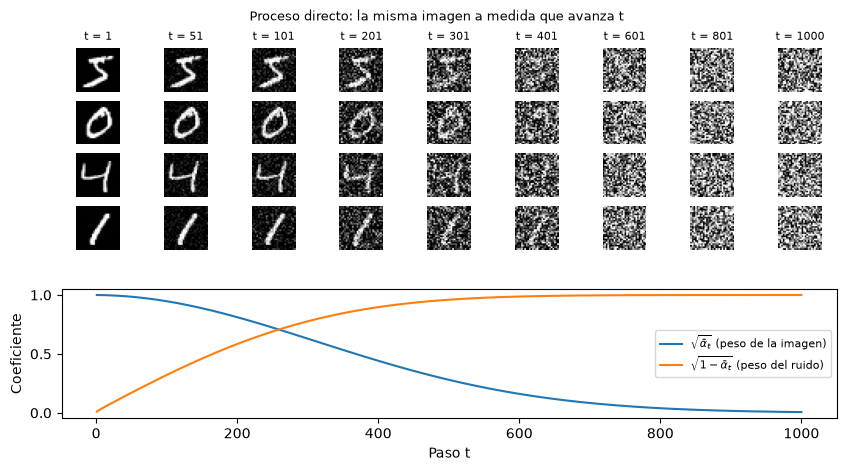

alfa_bar en t = 1: 0.9999 | en t = T: 4.0e-05 | señal y ruido pesan lo mismo en t = 260


In [3]:
T = 1000
betas = torch.linspace(1e-4, 0.02, T, device=device)
alfas = 1 - betas
alfa_bar = torch.cumprod(alfas, dim=0)

def difundir(x0, t, ruido):
    # Fórmula cerrada: x_t = sqrt(alfa_bar_t) x_0 + sqrt(1 - alfa_bar_t) eps, con un t distinto por imagen
    a = alfa_bar[t].view(-1, 1, 1, 1)
    return a.sqrt() * x0 + (1 - a).sqrt() * ruido

pasos_demo = [0, 50, 100, 200, 300, 400, 600, 800, 999]
g = torch.Generator(device=device).manual_seed(1)
x0 = X[:4].repeat_interleave(len(pasos_demo), 0)                          # 4 dígitos, cada uno en 9 pasos
t_demo = torch.tensor(pasos_demo, device=device).repeat(4)
xt = difundir(x0, t_demo, torch.randn(x0.shape, generator=g, device=device))

fig = plt.figure(figsize=(10, 4.6))
arriba, abajo = fig.subfigures(2, 1, height_ratios=[1.5, 1])
ejes = arriba.subplots(4, len(pasos_demo))
for k, ax in enumerate(ejes.flat):
    ax.imshow(xt[k, 0].cpu().add(1).div(2).clamp(0, 1), cmap="gray"); ax.axis("off")
    if k < len(pasos_demo):
        ax.set_title(f"t = {pasos_demo[k] + 1}", fontsize=8)
arriba.suptitle("Proceso directo: la misma imagen a medida que avanza t", fontsize=9)
arriba.subplots_adjust(top=0.84)
ax = abajo.subplots()
ax.plot(range(1, T + 1), alfa_bar.sqrt().cpu(), label=r"$\sqrt{\bar\alpha_t}$ (peso de la imagen)")
ax.plot(range(1, T + 1), (1 - alfa_bar).sqrt().cpu(), label=r"$\sqrt{1-\bar\alpha_t}$ (peso del ruido)")
ax.set_xlabel("Paso t"); ax.set_ylabel("Coeficiente"); ax.legend(fontsize=8)
abajo.subplots_adjust(bottom=0.25, top=0.95)
plt.show()

t_cruce = int((alfa_bar < 0.5).nonzero()[0]) + 1
print(f"alfa_bar en t = 1: {alfa_bar[0]:.4f} | en t = T: {alfa_bar[-1]:.1e} | señal y ruido pesan lo mismo en t = {t_cruce}")

La imagen se va disolviendo: en $t=101$ el dígito se ve con claridad bajo el ruido, en $t=301$ se intuye, en $t=401$ apenas, y desde $t=601$ no queda rastro visible. Al final $\bar\alpha_T\approx4\cdot10^{-5}$: de la imagen original queda menos del 1 % ($\sqrt{\bar\alpha_T}\approx0{,}006$), así que empezar a generar desde ruido $\mathcal{N}(\mathbf{0},\mathbf{I})$ es coherente con lo que la red ha visto. Señal y ruido pesan lo mismo hacia $t=260$; la programación lineal pasa cerca de la mitad de los pasos en zonas donde la imagen ya no se ve, una de las razones por las que existen programaciones alternativas (4.1).

### 3.3. Dos redes que predicen el ruido

Las dos reciben $\mathbf{x}_t$ y $t$ y devuelven un tensor de $1\times28\times28$ (el ruido predicho):

- **Red densa**: aplana la imagen, la proyecta a 1024 neuronas, le suma la proyección de la codificación sinusoidal de $t$ y la pasa por tres capas densas con SiLU. Ignora la estructura espacial.
- **U-Net pequeña**: bloques residuales con dos convoluciones, normalización por grupos (*GroupNorm*) y SiLU, en los que se suma la codificación de $t$; tres resoluciones ($28\to14\to7$, con 16, 32 y 64 canales) y conexiones de salto entre codificador y decodificador.

In [4]:
def codificar_paso(t, dim):
    # Codificación sinusoidal del paso (la misma que la posicional de los transformers)
    mitad = dim // 2
    frecuencias = torch.exp(-math.log(10000) * torch.arange(mitad, device=t.device) / mitad)
    angulos = t.float()[:, None] * frecuencias[None, :]
    return torch.cat([angulos.sin(), angulos.cos()], dim=-1)

class RedDensa(nn.Module):
    def __init__(self, oculta=1024, dim_t=128):
        super().__init__()
        self.dim_t = dim_t
        self.mlp_t = nn.Sequential(nn.Linear(dim_t, oculta), nn.SiLU(), nn.Linear(oculta, oculta))
        self.entrada = nn.Linear(784, oculta)
        self.cuerpo = nn.Sequential(
            nn.SiLU(), nn.Linear(oculta, oculta), nn.SiLU(), nn.Linear(oculta, oculta),
            nn.SiLU(), nn.Linear(oculta, 784))

    def forward(self, x, t):
        h = self.entrada(x.flatten(1)) + self.mlp_t(codificar_paso(t, self.dim_t))
        return self.cuerpo(h).view(-1, 1, 28, 28)

class BloqueResidual(nn.Module):
    def __init__(self, c_in, c_out, dim_t):
        super().__init__()
        self.conv1, self.conv2 = nn.Conv2d(c_in, c_out, 3, padding=1), nn.Conv2d(c_out, c_out, 3, padding=1)
        self.norm1, self.norm2 = nn.GroupNorm(8, c_out), nn.GroupNorm(8, c_out)
        self.proy_t = nn.Linear(dim_t, c_out)
        self.atajo = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x, emb_t):
        h = F.silu(self.norm1(self.conv1(x))) + self.proy_t(emb_t)[:, :, None, None]   # el paso t entra en cada bloque
        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.atajo(x)

class UNet(nn.Module):
    def __init__(self, c=16, dim_t=128):
        super().__init__()
        self.dim_t = dim_t
        self.mlp_t = nn.Sequential(nn.Linear(dim_t, dim_t), nn.SiLU(), nn.Linear(dim_t, dim_t))
        self.entrada = nn.Conv2d(1, c, 3, padding=1)
        self.cod1, self.bajar1 = BloqueResidual(c, c, dim_t), nn.Conv2d(c, 2 * c, 4, stride=2, padding=1)              # 28 -> 14
        self.cod2, self.bajar2 = BloqueResidual(2 * c, 2 * c, dim_t), nn.Conv2d(2 * c, 4 * c, 4, stride=2, padding=1)  # 14 -> 7
        self.medio = BloqueResidual(4 * c, 4 * c, dim_t)
        self.subir2, self.dec2 = nn.ConvTranspose2d(4 * c, 2 * c, 4, stride=2, padding=1), BloqueResidual(4 * c, 2 * c, dim_t)  # 7 -> 14
        self.subir1, self.dec1 = nn.ConvTranspose2d(2 * c, c, 4, stride=2, padding=1), BloqueResidual(2 * c, c, dim_t)          # 14 -> 28
        self.salida = nn.Conv2d(c, 1, 3, padding=1)

    def forward(self, x, t):
        emb_t = self.mlp_t(codificar_paso(t, self.dim_t))
        h1 = self.cod1(self.entrada(x), emb_t)
        h2 = self.cod2(self.bajar1(h1), emb_t)
        h = self.medio(self.bajar2(h2), emb_t)
        h = self.dec2(torch.cat([self.subir2(h), h2], dim=1), emb_t)          # conexión de salto
        h = self.dec1(torch.cat([self.subir1(h), h1], dim=1), emb_t)
        return self.salida(h)

for nombre, red in [("Red densa", RedDensa()), ("U-Net", UNet())]:
    print(f"{nombre}: {sum(p.numel() for p in red.parameters()):,} parámetros")

Red densa: 4,888,336 parámetros
U-Net: 270,929 parámetros


### 3.4. Entrenamiento y muestreo

El bucle de entrenamiento es el de 2.3, con Adam, lotes de 128, 10 épocas y una tasa de aprendizaje que baja hasta 0 siguiendo un coseno (de $10^{-3}$ en la red densa y $2\cdot10^{-3}$ en la U-Net; la demo de 4.2 muestra por qué conviene que baje). El muestreo DDPM sigue 2.2 y el DDIM, 2.5. Durante el entrenamiento, al final de cada época se generan 1 000 imágenes con DDIM de 25 pasos (rápido) para seguir la distancia de Fréchet.

In [5]:
@torch.no_grad()
def muestrear_ddpm(red, n, semilla=123, guardar=()):
    # Proceso inverso completo: T pasadas por la red. Devuelve también las imágenes intermedias de los pasos en `guardar`
    red.eval()
    g = torch.Generator(device=device).manual_seed(semilla)
    x = torch.randn(n, 1, 28, 28, generator=g, device=device)
    intermedias = {}
    for t in reversed(range(T)):
        eps = red(x, torch.full((n,), t, device=device))
        x = (x - betas[t] / (1 - alfa_bar[t]).sqrt() * eps) / alfas[t].sqrt()          # media mu_theta
        if t > 0:                                                                        # sin ruido en el último paso
            x = x + betas[t].sqrt() * torch.randn(x.shape, generator=g, device=device)
        if t in guardar:
            intermedias[t] = x.clone()
    return x.clamp(-1, 1), intermedias

@torch.no_grad()
def muestrear_ddim(red, n, pasos, semilla=123):
    # Muestreo determinista con `pasos` pasadas, saltando pasos de la programación
    red.eval()
    g = torch.Generator(device=device).manual_seed(semilla)
    x = torch.randn(n, 1, 28, 28, generator=g, device=device)
    ts = torch.linspace(T - 1, 0, pasos, device=device).long()
    for k, t in enumerate(ts):
        a_t = alfa_bar[t]
        a_s = alfa_bar[ts[k + 1]] if k + 1 < pasos else torch.tensor(1.0, device=device)
        eps = red(x, t.repeat(n))
        x0_est = (x - (1 - a_t).sqrt() * eps) / a_t.sqrt()                    # sin recortar: ver 4.2
        x = a_s.sqrt() * x0_est + (1 - a_s).sqrt() * eps
    return x.clamp(-1, 1)

def entrenar_difusion(fabrica, epocas, lr, semilla=0, coseno=True, ema=None):
    # coseno: la tasa de aprendizaje baja hasta 0 a lo largo del entrenamiento; ema: decaimiento de la media móvil de los pesos
    torch.manual_seed(semilla)
    red = fabrica().to(device)
    opt = torch.optim.Adam(red.parameters(), lr=lr)
    lotes_por_epoca = math.ceil(len(X) / 128)
    programa = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epocas * lotes_por_epoca) if coseno else None
    promedio = torch.optim.swa_utils.AveragedModel(red, multi_avg_fn=torch.optim.swa_utils.get_ema_multi_avg_fn(ema)) if ema else None
    historia = []
    for epoca in range(1, epocas + 1):
        red.train()
        suma = 0.0
        for i in torch.randperm(len(X), device=device).split(128):
            x0 = X[i]
            t = torch.randint(0, T, (len(i),), device=device)                 # un paso al azar por imagen
            ruido = torch.randn_like(x0)
            perdida = F.mse_loss(red(difundir(x0, t, ruido), t), ruido)
            opt.zero_grad(); perdida.backward(); opt.step()
            if programa:
                programa.step()
            if promedio:
                promedio.update_parameters(red)
            suma += perdida.item()
        fila = {"época": epoca, "pérdida": suma / lotes_por_epoca}
        if not promedio:
            fila["Fréchet (DDIM 25, n = 1000)"] = distancia_frechet(analizar(muestrear_ddim(red, 1000, 25))[0], caract_test[:1000])
        historia.append(fila)
    return red, pd.DataFrame(historia).set_index("época"), (promedio.module if promedio else None)

modelos, historias = {}, {}
for nombre, fabrica, lr in [("Red densa", RedDensa, 1e-3), ("U-Net", UNet, 2e-3)]:
    inicio = time.time()
    modelos[nombre], historias[nombre], _ = entrenar_difusion(fabrica, epocas=10, lr=lr)
    print(f"{nombre}: entrenada en {time.time() - inicio:.0f} s")
pd.concat(historias, axis=1).iloc[[0, 1, 3, 5, 7, 9]].round(4)

Red densa: entrenada en 13 s


U-Net: entrenada en 79 s


Red densa                               U-Net  \
        pérdida Fréchet (DDIM 25, n = 1000) pérdida   
época                                                 
1        0.6815                   1903.0516  0.0587   
2        0.4854                   1811.6955  0.0316   
4        0.3075                   1703.4889  0.0274   
6        0.2385                   1521.4638  0.0258   
8        0.2024                   1455.4407  0.0247   
10       0.1877                   1426.6483  0.0240   

                                   
      Fréchet (DDIM 25, n = 1000)  
época                              
1                        471.0343  
2                        377.4196  
4                        114.0968  
6                         68.2064  
8                         55.8526  
10                        46.6925

La U-Net aprende mucho más deprisa y mucho mejor: su pérdida es de 0,059 en la primera época y 0,024 en la última, frente a 0,68 y 0,19 de la red densa, que tiene 18 veces más parámetros (4,9 millones frente a 271 000). La distancia de Fréchet de la U-Net (con 1 000 imágenes, suelo 41,7) baja de 471 a 46,7; la de la red densa no baja de 1 400: no genera nada parecido a un dígito.

Fíjate en la U-Net entre las épocas 2 y 10: la pérdida solo baja un 24 % (de 0,0316 a 0,0240) mientras la distancia de Fréchet se divide por 8 (de 377 a 46,7). La pérdida media apenas se mueve cuando las muestras más mejoran; 3.6 explica por qué.

### 3.5. Generar: el proceso inverso

Generamos 2 000 imágenes con cada red usando el muestreo DDPM completo (1 000 pasos) y guardamos algunos pasos intermedios para ver cómo emerge un dígito del ruido.

Red densa: 2 000 imágenes con 1 000 pasos en 6 s


U-Net: 2 000 imágenes con 1 000 pasos en 97 s


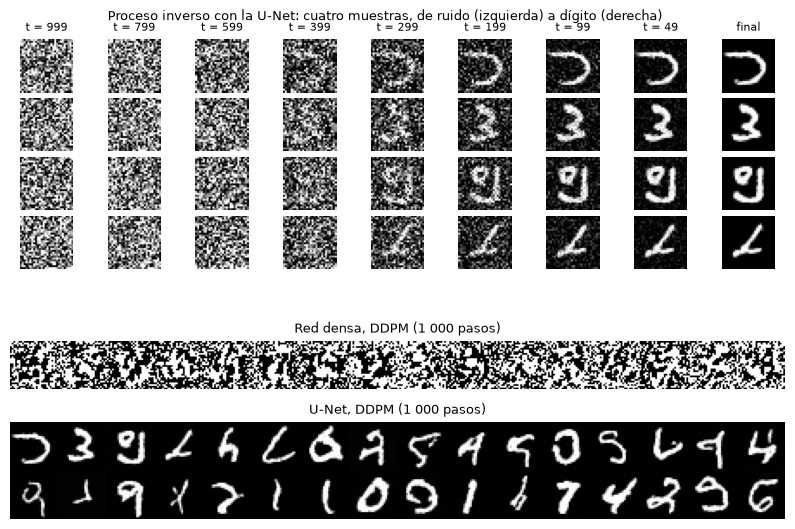

In [6]:
pasos_guardados = [999, 799, 599, 399, 299, 199, 99, 49, 0]
muestras, tiempos = {}, {}
for nombre, red in modelos.items():
    inicio = time.time()
    muestras[nombre], intermedias = muestrear_ddpm(red, 2000, guardar=pasos_guardados if nombre == "U-Net" else ())
    if device == "cuda":
        torch.cuda.synchronize()
    tiempos[nombre] = time.time() - inicio
    print(f"{nombre}: 2 000 imágenes con 1 000 pasos en {tiempos[nombre]:.0f} s")

fig = plt.figure(figsize=(10, 5.6))
arriba, abajo = fig.subfigures(2, 1, height_ratios=[1.6, 1.4])
ejes = arriba.subplots(4, len(pasos_guardados))
for col, t in enumerate(pasos_guardados):
    for fila in range(4):
        ax = ejes[fila, col]
        ax.imshow(intermedias[t][fila, 0].cpu().add(1).div(2).clamp(0, 1), cmap="gray"); ax.axis("off")
    ejes[0, col].set_title(f"t = {t}" if t else "final", fontsize=8)
arriba.suptitle("Proceso inverso con la U-Net: cuatro muestras, de ruido (izquierda) a dígito (derecha)", fontsize=9)
arriba.subplots_adjust(top=0.88, hspace=0.1)
ax1, ax2 = abajo.subplots(2, 1, height_ratios=[1, 2])
mostrar(muestras["Red densa"], "Red densa, DDPM (1 000 pasos)", filas=1, ax=ax1)
mostrar(muestras["U-Net"], "U-Net, DDPM (1 000 pasos)", ax=ax2)
plt.show()

El dígito no aparece de golpe ni de forma uniforme. Hasta $t\approx400$ todo parece ruido; entre $t=299$ y $t=199$ surge la **forma gruesa** (el trazo y su posición) y los últimos 200 pasos solo **limpian** el fondo y afinan los bordes. Es decir, los pasos con mucho ruido deciden la estructura y los de poco ruido, los detalles.

Las muestras de la U-Net son en su mayoría dígitos reconocibles y variados, con trazos limpios; algunas son formas ambiguas que no corresponden a ningún dígito. La red densa solo produce ruido saturado: 1 000 pasos aplicando una predicción de ruido mala acumulan el error en lugar de corregirlo.

### 3.6. ¿Qué aprende la red en cada nivel de ruido?

La pérdida de entrenamiento es una media sobre todos los $t$. Desglosarla por paso, con imágenes de test y un ruido fijo, enseña dónde está la dificultad.

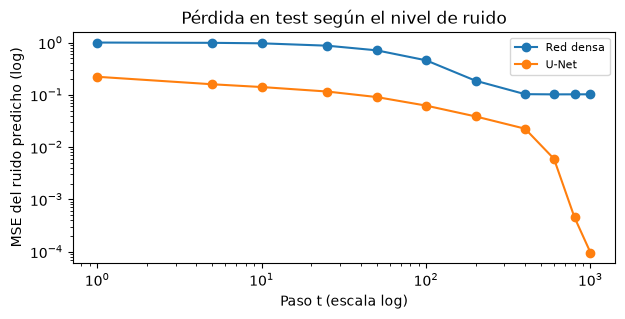

t,1,5,10,25,50,100,200,400,600,800,1000
Red densa,0.999,0.987,0.965,0.870,0.709,0.457,0.186,0.103,0.102,0.102,0.102
U-Net,0.221,0.159,0.141,0.115,0.091,0.062,0.039,0.022,0.006,0.000,0.000


In [7]:
pasos_eval = [0, 4, 9, 24, 49, 99, 199, 399, 599, 799, 999]
g = torch.Generator(device=device).manual_seed(2)
x0, ruido = X_test[:2000], torch.randn(2000, 1, 28, 28, generator=g, device=device)
perdida_por_paso = {}
with torch.no_grad():
    for nombre, red in modelos.items():
        red.eval()
        perdida_por_paso[nombre] = [F.mse_loss(red(difundir(x0, torch.full((2000,), t, device=device), ruido),
                                                   torch.full((2000,), t, device=device)), ruido).item() for t in pasos_eval]

fig, ax = plt.subplots(figsize=(7, 3))
for nombre, valores in perdida_por_paso.items():
    ax.plot([t + 1 for t in pasos_eval], valores, marker="o", label=nombre)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Paso t (escala log)"); ax.set_ylabel("MSE del ruido predicho (log)")
ax.set_title("Pérdida en test según el nivel de ruido"); ax.legend(fontsize=8)
plt.show()
pd.DataFrame(perdida_por_paso, index=pd.Index([t + 1 for t in pasos_eval], name="t")).T.round(3)

La dificultad depende muchísimo del nivel de ruido:

- **$t$ grande** (casi todo ruido): $\mathbf{x}_t\approx\boldsymbol{\epsilon}$, así que predecir el ruido es casi copiar la entrada. La U-Net lo hace casi perfecto (MSE de 0,006 en $t=600$ y prácticamente 0 en $t=1000$); la red densa ni siquiera aprende a copiar (0,10).
- **$t$ pequeño** (casi la imagen limpia): el ruido es una perturbación diminuta, difícil de separar de los detalles del trazo. La U-Net tiene un MSE de 0,22 en $t=1$; la red densa, 0,999, lo mismo que predecir siempre cero (el ruido tiene varianza 1): no ha aprendido nada en esos pasos.

La pérdida de entrenamiento promedia todos los pasos con el mismo peso, así que la dominan los $t$ pequeños, cuyo error es en gran parte irreducible. Por eso apenas baja aunque la red siga mejorando en los pasos intermedios (100–400), que son los que deciden la forma del dígito.

### 3.7. Muestreo acelerado con DDIM

La misma U-Net, sin reentrenar, muestreada con DDIM y distinto número de pasos. Mismas 2 000 imágenes y mismo ruido inicial en todos los casos.

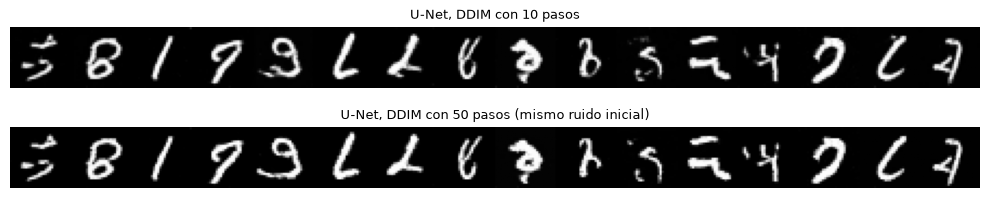

,pasadas por la red,segundos,Fréchet
"DDPM, 1 000 pasos",1000.0,97.1,28.3
"DDIM, 10 pasos",10.0,1.0,57.8
"DDIM, 25 pasos",25.0,2.4,39.9
"DDIM, 50 pasos",50.0,4.9,37.1
"DDIM, 100 pasos",100.0,9.7,36.1
"DDIM, 250 pasos",250.0,24.3,35.6


In [8]:
filas = {"DDPM, 1 000 pasos": {"pasadas por la red": T, "segundos": tiempos["U-Net"],
                               "Fréchet": distancia_frechet(analizar(muestras["U-Net"])[0], caract_test[:2000])}}
muestras_ddim = {}
for pasos in (10, 25, 50, 100, 250):
    inicio = time.time()
    muestras_ddim[pasos] = muestrear_ddim(modelos["U-Net"], 2000, pasos)
    if device == "cuda":
        torch.cuda.synchronize()
    filas[f"DDIM, {pasos} pasos"] = {"pasadas por la red": pasos, "segundos": time.time() - inicio,
                                     "Fréchet": distancia_frechet(analizar(muestras_ddim[pasos])[0], caract_test[:2000])}

fig, axes = plt.subplots(2, 1, figsize=(10, 2.3))
mostrar(muestras_ddim[10], "U-Net, DDIM con 10 pasos", filas=1, ax=axes[0])
mostrar(muestras_ddim[50], "U-Net, DDIM con 50 pasos (mismo ruido inicial)", filas=1, ax=axes[1])
plt.tight_layout()
plt.show()
pd.DataFrame(filas).T.round({"segundos": 1, "Fréchet": 1})

La misma red, sin reentrenar, genera con DDIM 50 pasos en 4,9 s en lugar de 97 s: **20 veces más rápido**, con una distancia de Fréchet de 37,1 frente a 28,3 del DDPM. Con 10 pasos (1,0 s) la calidad cae a 57,8; a partir de 50 pasos apenas mejora (36,1 con 100 y 35,6 con 250).

Como el muestreo DDIM es determinista, el mismo ruido inicial da el **mismo dígito** con 10 que con 50 pasos (las dos filas de la figura): el número de pasos solo cambia la precisión con la que se recorre el camino, no adónde lleva. Incluso con 250 pasos, DDIM queda por detrás del DDPM: el ruido que el DDPM vuelve a añadir en cada paso ayuda a corregir los errores que la red va acumulando, mientras que DDIM los arrastra hasta el final.

### 3.8. Difusión frente a GAN

Entrenamos la DCGAN del [notebook de GAN](08-gan.ipynb#3.4.-DCGAN:-una-GAN-convolucional) (misma arquitectura, misma receta, 15 épocas) y la evaluamos igual que a la difusión: 2 000 imágenes, distancia de Fréchet, tiempo de generación y reparto de dígitos según el juez. Para estimar cuánto varía la distancia de Fréchet solo por las 2 000 imágenes elegidas, la calculamos con tres semillas de muestreo en los modelos rápidos y con tres subconjuntos de imágenes reales.

In [9]:
LATENTE = 64
G = nn.Sequential(
    nn.Linear(LATENTE, 128 * 7 * 7), nn.Unflatten(1, (128, 7, 7)), nn.BatchNorm2d(128), nn.ReLU(),
    nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
    nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1), nn.Tanh()).to(device)
D = nn.Sequential(
    nn.Conv2d(1, 64, 4, stride=2, padding=1), nn.LeakyReLU(0.2),
    nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.LeakyReLU(0.2),
    nn.Flatten(), nn.Linear(128 * 7 * 7, 1)).to(device)

torch.manual_seed(0)
inicio = time.time()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()
for epoca in range(15):
    for i in torch.randperm(len(X), device=device).split(128):
        unos, ceros = torch.ones(len(i), 1, device=device), torch.zeros(len(i), 1, device=device)
        falsas = G(torch.randn(len(i), LATENTE, device=device))
        perdida_D = bce(D(X[i]), unos) + bce(D(falsas.detach()), ceros)
        opt_D.zero_grad(); perdida_D.backward(); opt_D.step()
        perdida_G = bce(D(falsas), unos)
        opt_G.zero_grad(); perdida_G.backward(); opt_G.step()
G.eval()
print(f"DCGAN entrenada en {time.time() - inicio:.0f} s")

@torch.no_grad()
def generar_gan(n, semilla):
    return G(torch.randn(n, LATENTE, generator=torch.Generator(device=device).manual_seed(semilla), device=device))

inicio = time.time()
muestras_gan = generar_gan(2000, 123)
if device == "cuda":
    torch.cuda.synchronize()
tiempo_gan = time.time() - inicio

fre = lambda imgs: distancia_frechet(analizar(imgs)[0], caract_test[:2000])
variacion = {
    "Reales (entrenamiento)": [distancia_frechet(caract_train[k * 2000:(k + 1) * 2000], caract_test[:2000]) for k in range(3)],
    "DCGAN": [fre(generar_gan(2000, s)) for s in (123, 1, 2)],
    "U-Net, DDIM 50 pasos": [fre(muestras_ddim[50])] + [fre(muestrear_ddim(modelos["U-Net"], 2000, 50, semilla=s)) for s in (1, 2)],
}
print("Fréchet con 2 000 imágenes y tres semillas o subconjuntos:")
for nombre, v in variacion.items():
    print(f"  {nombre:<24} {np.round(v, 1)}  media {np.mean(v):.1f}")

DCGAN entrenada en 46 s


Fréchet con 2 000 imágenes y tres semillas o subconjuntos:
  Reales (entrenamiento)   [29.1 22.9 29.1]  media 27.0
  DCGAN                    [56.5 56.6 55.2]  media 56.1
  U-Net, DDIM 50 pasos     [37.1 35.1 35. ]  media 35.7


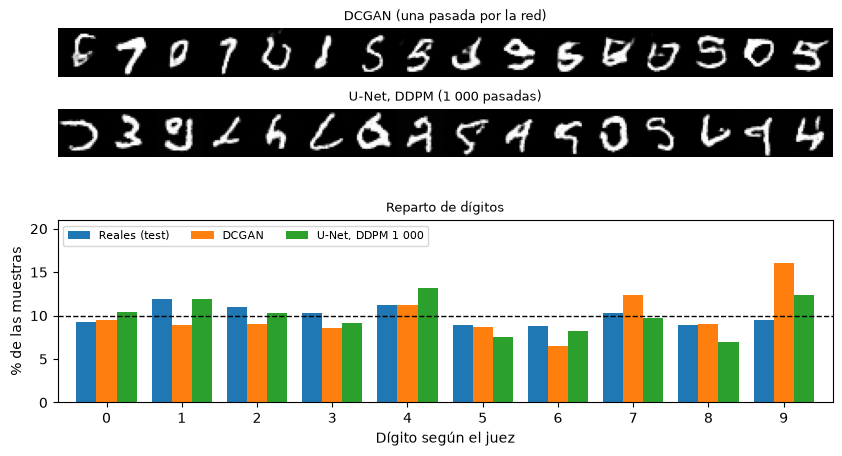

,Fréchet (n = 2 000),segundos para 2 000,confianza media,dígito más frecuente (%),dígito menos frecuente (%)
Reales (test),NaN,NaN,0.98,11.9,8.75
DCGAN,56.54,0.10,0.86,16.0,6.55
"Difusión densa, DDPM 1 000",1399.90,5.80,0.88,78.4,0.10
"U-Net, DDIM 50",37.12,4.85,0.87,12.7,7.75
"U-Net, DDPM 1 000",28.27,97.12,0.89,13.2,7.00


In [10]:
resumen, repartos = {}, {}
candidatos = [("Reales (test)", X_test[:2000], None), ("DCGAN", muestras_gan, tiempo_gan),
              ("Difusión densa, DDPM 1 000", muestras["Red densa"], tiempos["Red densa"]),
              ("U-Net, DDIM 50", muestras_ddim[50], filas["DDIM, 50 pasos"]["segundos"]),
              ("U-Net, DDPM 1 000", muestras["U-Net"], tiempos["U-Net"])]
for nombre, imgs, segundos in candidatos:
    caract, prob = analizar(imgs)
    repartos[nombre] = torch.bincount(prob.argmax(1), minlength=10).numpy() / len(prob)
    resumen[nombre] = {"Fréchet (n = 2 000)": distancia_frechet(caract, caract_test[:2000]) if segundos else np.nan,
                       "segundos para 2 000": segundos,
                       "confianza media": prob.max(1).values.mean().item(),
                       "dígito más frecuente (%)": 100 * repartos[nombre].max(),
                       "dígito menos frecuente (%)": 100 * repartos[nombre].min()}

fig = plt.figure(figsize=(10, 4.6))
arriba, abajo = fig.subfigures(2, 1, height_ratios=[1, 1.4])
ax1, ax2 = arriba.subplots(2, 1)
mostrar(muestras_gan, "DCGAN (una pasada por la red)", filas=1, ax=ax1)
mostrar(muestras["U-Net"], "U-Net, DDPM (1 000 pasadas)", filas=1, ax=ax2)
ax = abajo.subplots()
pd.DataFrame({k: repartos[k] for k in ["Reales (test)", "DCGAN", "U-Net, DDPM 1 000"]}, index=range(10)).mul(100).plot.bar(ax=ax, width=0.8)
ax.axhline(10, color="k", ls="--", lw=1)
ax.set_xlabel("Dígito según el juez"); ax.set_ylabel("% de las muestras"); ax.set_title("Reparto de dígitos", fontsize=9)
ax.set_ylim(0, 21); ax.tick_params(axis="x", rotation=0); ax.legend(fontsize=8, ncol=3, loc="upper left")
abajo.subplots_adjust(bottom=0.2)
plt.show()
pd.DataFrame(resumen).T.round(2)

Con 2 000 imágenes, la distancia de Fréchet varía poco con la semilla: entre 55,2 y 56,6 en la DCGAN y entre 35,0 y 37,1 en DDIM con 50 pasos. Entre subconjuntos de imágenes reales va de 22,9 a 29,1. Las diferencias entre modelos son mucho mayores que esa variación, aunque cada modelo se ha entrenado una sola vez:

- **Calidad.** El DDPM con la U-Net (28,3) cae dentro del rango de dos conjuntos de imágenes reales; DDIM con 50 pasos (37,1) queda cerca, y la DCGAN (56,5) claramente por detrás. La confianza media del juez (0,89 con el DDPM, 0,86 con la DCGAN, 0,98 con imágenes reales) indica que los dos modelos siguen generando algunos dígitos ambiguos.
- **Diversidad.** El reparto de dígitos del DDPM (entre el 7,0 % y el 13,2 %) se parece más al de las imágenes reales (8,75–11,9 %) que el de la DCGAN, que genera demasiados 9 (16,0 %) y pocos 6 (6,55 %).
- **Velocidad.** La DCGAN genera 2 000 imágenes en 0,10 s, unas 1 000 veces más rápido que el DDPM (97 s) y 50 veces más rápido que DDIM con 50 pasos (4,85 s).
- La difusión con red densa sirve de aviso sobre el juez: sus imágenes son ruido, pero el juez las clasifica con una confianza media de 0,88 y mete el 78,4 % en un mismo dígito. Un clasificador no sabe decir "esto no es un dígito"; la distancia de Fréchet (1 400) sí delata el problema.

El coste de entrenamiento es del mismo orden: 46 s la DCGAN y 79 s la U-Net (incluido el seguimiento de la distancia de Fréchet en cada época), y la difusión no necesita vigilar el equilibrio entre dos redes.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Consejo |
|---|---|---|
| Número de pasos $T$ | Finura del proceso directo; con muestreo DDPM, también el coste de generar | 1000 es el estándar; con DDIM se entrena con $T=1000$ y se muestrea con 50–250 pasos |
| Programación de $\beta_t$ (*noise schedule*) | Ritmo al que se destruye la imagen | Lineal $10^{-4}\to0{,}02$ (DDPM); la de coseno (Nichol y Dhariwal, 2021) destruye más despacio al principio y desperdicia menos pasos en ruido casi puro, y suele funcionar mejor en imágenes pequeñas |
| Qué predice la red | Escala del objetivo de regresión | El ruido $\boldsymbol{\epsilon}$ (estándar); alternativas: la imagen limpia $\mathbf{x}_0$ o la "velocidad" $\mathbf{v}$ |
| Arquitectura | Capacidad de quitar ruido respetando la estructura | U-Net con bloques residuales, codificación de $t$ en cada bloque y, en imágenes grandes, capas de atención en las resoluciones bajas |
| Tasa de aprendizaje | Estabilidad y calidad final | Adam con $10^{-4}$–$2\cdot10^{-3}$; que baje al final del entrenamiento (coseno) o usar EMA |
| Media móvil exponencial de los pesos (EMA) | Calidad de las muestras | Promediar los pesos (decaimiento 0,999–0,9999) mejora mucho las muestras cuando la tasa de aprendizaje no baja al final (demo de 4.2); es estándar en los modelos grandes |
| Pasos de muestreo y muestreador | Compromiso calidad/tiempo | DDPM con todos los pasos para la mejor calidad; DDIM u otros muestreadores rápidos (DPM-Solver) con 10–100 pasos para generar deprisa |
| Rango de los datos | Coherencia con el ruido $\mathcal{N}(\mathbf{0},\mathbf{I})$ | Píxeles en $[-1,1]$ y recorte (*clamp*) al final del muestreo |

### 4.2. Errores comunes

- **Leer la meseta de la pérdida media como "ya no aprende".** La pérdida de entrenamiento mezcla todos los pasos: la dominan los $t$ pequeños, donde el ruido es casi imposible de predecir, y apenas se mueve aunque la red siga mejorando en los pasos intermedios, que son los que deciden la forma del dígito (3.6). En 3.4, la pérdida de la U-Net solo baja un 24 % entre las épocas 2 y 10 mientras la distancia de Fréchet se divide por 8. Para decidir cuánto entrenar hay que mirar las muestras o una métrica como la distancia de Fréchet, no solo la curva de pérdida.
- **Usar una red densa enorme como predictora de ruido.** Una red densa trata cada píxel por separado y no aprovecha que los trazos son locales ni que el mismo patrón puede aparecer en cualquier posición. Aquí, con 4,9 millones de parámetros (18 veces los 271 000 de la U-Net), no genera más que ruido: ni siquiera aprende a devolver la entrada en los $t$ grandes (3.6). Una red densa mucho mayor y entrenada más tiempo llega a dígitos reconocibles pero borrosos, y sigue lejos de una U-Net pequeña.
- **Comparar la difusión con una GAN que no funciona.** Si la GAN tiene un error (por ejemplo, el de la sigmoide de más y el `detach` mal colocado del [notebook de GAN](08-gan.ipynb#4.2.-Errores-comunes)) y solo genera ruido, la comparación dice "difusión 10, GAN 0" y no enseña nada. Antes de comparar hay que asegurarse de que las dos partes funcionan; con una DCGAN correcta, la difusión sigue ganando en calidad y diversidad, pero por un margen razonable, y la GAN gana con claridad en velocidad (3.8).
- **Comparar distancias de Fréchet calculadas con distinto número de imágenes.** El valor depende mucho de $n$: entre dos conjuntos reales sale 2,90 con 10 000 imágenes y 29,10 con 2 000 (3.1). Un 60 con 10 000 imágenes, como el de la DCGAN del notebook de GAN, y un 56,5 con 2 000, como el de 3.8, no se pueden comparar.
- **Desfasar los índices de los pasos.** Las fórmulas cuentan los pasos de 1 a $T$ y los tensores de 0 a $T-1$. Si el entrenamiento usa `alfa_bar[t]` y el muestreo `alfa_bar[t - 1]` (o $t$ va hasta $T$ en uno y hasta $T-1$ en otro), la red quita en cada paso un ruido que no corresponde. Hay que fijar un convenio y usarlo en todas las funciones.
- **Etiquetar mal las imágenes intermedias.** Al dibujar el proceso inverso, calcular la etiqueta de cada columna con una fórmula aparte (por ejemplo `T - columna * 30`) acaba desfasada respecto a los pasos guardados; es mejor guardar cada imagen junto a su $t$, como hace `muestrear_ddpm` con un diccionario.
- **Olvidar `torch.no_grad()` al muestrear.** Sin él, PyTorch guarda el grafo de las 1000 pasadas para un posible `backward` y la memoria crece hasta agotarse. También hay que poner la red en modo evaluación.
- **Recortar $\hat{\mathbf{x}}_0$ en DDIM sin recalcular el ruido.** Recortar la estimación de la imagen limpia a $[-1,1]$ en cada paso parece inofensivo, pero si el paso siguiente usa el ruido predicho original, imagen y ruido dejan de ser coherentes y el error se acumula: en una primera versión de este notebook, más pasos de DDIM daban **peores** muestras en lugar de mejores. O se recalcula el ruido a partir de la imagen recortada, o se recorta solo el resultado final, como hace `muestrear_ddim`.
- **Añadir ruido en el último paso**, o no recortar el resultado a $[-1,1]$: la imagen final queda con grano o con píxeles fuera de rango.

#### Demo: tasa de aprendizaje constante

La misma U-Net y las mismas 10 épocas, pero con la tasa de aprendizaje fija en $10^{-3}$ en lugar del programa coseno, guardando a la vez una media móvil exponencial de los pesos (decaimiento 0,999).

In [11]:
inicio = time.time()
red_cte, hist_cte, red_ema = entrenar_difusion(UNet, epocas=10, lr=1e-3, coseno=False, ema=0.999)
print(f"Entrenada en {time.time() - inicio:.0f} s; pérdida en la última época: {hist_cte['pérdida'].iloc[-1]:.4f} "
      f"(con programa coseno: {historias['U-Net']['pérdida'].iloc[-1]:.4f})")
for nombre, red in [("lr constante, pesos finales", red_cte), ("lr constante, media móvil (EMA)", red_ema),
                    ("programa coseno, pesos finales", modelos["U-Net"])]:
    print(f"{nombre:<32} Fréchet DDIM 50 pasos (n = 2 000): {fre(muestrear_ddim(red, 2000, 50)):6.1f}")

Entrenada en 67 s; pérdida en la última época: 0.0253 (con programa coseno: 0.0240)


lr constante, pesos finales      Fréchet DDIM 50 pasos (n = 2 000):  145.9


lr constante, media móvil (EMA)  Fréchet DDIM 50 pasos (n = 2 000):   55.8


programa coseno, pesos finales   Fréchet DDIM 50 pasos (n = 2 000):   37.1


Con la tasa de aprendizaje constante, la pérdida final es casi la misma (0,0253 frente a 0,0240), pero los pesos finales dan una distancia de Fréchet de 145,9 frente a 37,1: cuatro veces peor. Con una tasa de aprendizaje fija, los pesos siguen oscilando alrededor del mínimo, y una predicción de ruido algo desviada, aplicada en 50 (o 1 000) pasos encadenados, desvía las muestras mucho más de lo que sugiere la pérdida de un solo paso. Hay dos remedios: que la tasa de aprendizaje baje al final (programa coseno, como en 3.4) o muestrear con la **media móvil** de los pesos, que suaviza esa oscilación (55,8). Los modelos de difusión grandes usan casi siempre la media móvil.

## 5. Comparación con métodos relacionados

| Modelo | Calidad de las muestras | Diversidad | Velocidad al generar | Estabilidad del entrenamiento | Da la probabilidad de los datos | Cuándo usarlo |
|---|---|---|---|---|---|---|
| **[Autoencoder variacional (VAE)](05-autoencoders.ipynb)** | Media (borrosas) | Alta | Muy rápida (una pasada) | Alta | Una cota inferior | Espacio latente útil, generación rápida sin gran detalle |
| **[GAN](08-gan.ipynb)** | Alta (nítidas) | Riesgo de colapso de modos | Muy rápida (una pasada) | Baja | No | Generación en tiempo real, superresolución, traducción entre imágenes |
| **Difusión (DDPM)** | Muy alta | Alta | Lenta (cientos o miles de pasadas) | Alta (una sola pérdida MSE) | Una cota inferior | Máxima calidad cuando el tiempo de generación no importa |
| **Difusión con DDIM u otros muestreadores rápidos** | Alta | Alta | Media (10–100 pasadas) | La misma red | Una cota inferior | El uso práctico habitual de un modelo de difusión |
| **Difusión latente** (Stable Diffusion) | Muy alta | Alta | Media | Alta | Una cota inferior | Imágenes grandes: la difusión se hace en el espacio latente de un autoencoder, mucho más pequeño que los píxeles |
| **Autorregresivos** ([transformers](07-atencion-y-transformers.ipynb)) | Alta | Alta | Lenta (un elemento cada vez) | Alta | Sí, exacta | Texto; imagen y audio como secuencias de *tokens* |

## 6. Referencias

### Fuentes

- LeCun, Y., Bottou, L., Bengio, Y. y Haffner, P. (1998). «Gradient-based learning applied to document recognition». *Proceedings of the IEEE*, 86(11), 2278–2324. Origen de MNIST, descargado con [`torchvision.datasets.MNIST`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html).
- PyTorch: [`nn.GroupNorm`](https://pytorch.org/docs/stable/generated/torch.nn.GroupNorm.html), [`nn.ConvTranspose2d`](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), [`nn.SiLU`](https://pytorch.org/docs/stable/generated/torch.nn.SiLU.html), [`torch.no_grad`](https://pytorch.org/docs/stable/generated/torch.no_grad.html), [`torch.Generator`](https://pytorch.org/docs/stable/generated/torch.Generator.html), [`CosineAnnealingLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html) y [`AveragedModel`](https://pytorch.org/docs/stable/generated/torch.optim.swa_utils.AveragedModel.html) (media móvil de los pesos). SciPy: [`scipy.linalg.sqrtm`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.sqrtm.html).

### Para saber más

- Ho, J., Jain, A. y Abbeel, P. (2020). [«Denoising diffusion probabilistic models»](https://arxiv.org/abs/2006.11239). *Advances in Neural Information Processing Systems* 33 (NeurIPS 2020), 6840–6851. El DDPM: la pérdida simplificada de predicción del ruido y el algoritmo de muestreo de este notebook.
- Song, J., Meng, C. y Ermon, S. (2021). [«Denoising diffusion implicit models»](https://arxiv.org/abs/2010.02502). *International Conference on Learning Representations (ICLR)*. El DDIM: muestreo determinista con muchos menos pasos usando la misma red entrenada.